## **Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Import Libraries**

In [ ]:
!pip install "transformers==4.44.2" datasets seqeval accelerate lime tokenizers pytorch-crf -q

In [ ]:
import os, json, re, math, time, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from transformers import (
    AutoTokenizer,
    BloomPreTrainedModel,
    BloomModel,
    BloomConfig,
    get_cosine_schedule_with_warmup,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_curve, f1_score
)
from seqeval.metrics import (
    precision_score as seqeval_precision,
    recall_score    as seqeval_recall,
    f1_score        as seqeval_f1,
    classification_report as seqeval_report
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
if not hasattr(sys.modules["__main__"], "__file__"):
    sys.modules["__main__"].__file__ = "colab_notebook.py"
print("✅ All libraries imported.")

✅ All libraries imported.


## **Setup: Path, Device, AMP Constants**

In [ ]:
BASE_DIR         = '/content/drive/MyDrive/Colab Datasets'
BIO_DIR          = f'{BASE_DIR}/BIO Splits v2'
CKPT_DIR         = f'{BASE_DIR}/Checkpoints v2'
RESULT_DIR       = f'{BASE_DIR}/Results v2'
MODEL_NAME       = 'bigscience/bloom-560m'
LOCAL_BLOOM_PATH = f'{BASE_DIR}/bloom-560m-local'
MAX_LENGTH       = 512
IGNORE_IDX       = -100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_WORKERS = 0 if DEVICE.type == 'cpu' else 2
USE_AMP   = (DEVICE.type == 'cuda')
AMP_DTYPE = (
    torch.bfloat16
    if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported()
    else torch.float16
)
PREFETCH_FACTOR = 2 if N_WORKERS > 0 else None

os.makedirs(CKPT_DIR,   exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print(f'Device        : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'BF16 support  : {torch.cuda.is_bf16_supported()}')
else:
    print("⚠️  GPU tidak ditemukan. Switch ke A100/T4 sebelum training.")
print(f'AMP           : {USE_AMP}  dtype={AMP_DTYPE}')
print(f'N_WORKERS     : {N_WORKERS}')
print(f'BIO_DIR       : {BIO_DIR}')
print(f'CKPT_DIR      : {CKPT_DIR}')

Device        : cuda
GPU           : NVIDIA A100-SXM4-40GB
VRAM          : 42.4 GB
BF16 support  : True
AMP           : True  dtype=torch.bfloat16
N_WORKERS     : 2
BIO_DIR       : /content/drive/MyDrive/Colab Datasets/BIO Splits v2
CKPT_DIR      : /content/drive/MyDrive/Colab Datasets/Checkpoints v2


## **Load Tokenizer BLOOM**

In [ ]:
_tok_config_path = os.path.join(LOCAL_BLOOM_PATH, "tokenizer.json")
_tok_cfg_path    = os.path.join(LOCAL_BLOOM_PATH, "tokenizer_config.json")
_model_cfg_path  = os.path.join(LOCAL_BLOOM_PATH, "config.json")

if os.path.exists(_tok_cfg_path):
    with open(_tok_cfg_path, "r") as f:
        _cfg = json.load(f)
    if _cfg.get("tokenizer_class") in {"TokenizersBackend", None, ""}:
        _cfg["tokenizer_class"] = "BloomTokenizerFast"
        with open(_tok_cfg_path, "w") as f:
            json.dump(_cfg, f, indent=2)
        print("✅ tokenizer_config.json dipatch → BloomTokenizerFast")

if not os.path.exists(_model_cfg_path):
    with open(_model_cfg_path, "w") as f:
        json.dump({"model_type": "bloom"}, f, indent=2)
    print("✅ Stub config.json dibuat.")

if os.path.exists(_tok_config_path):
    try:
        from transformers import BloomTokenizerFast
        tokenizer = BloomTokenizerFast.from_pretrained(LOCAL_BLOOM_PATH)
        print(f"✅ Tokenizer dimuat dari lokal: {LOCAL_BLOOM_PATH}")
    except Exception as e:
        print(f"⚠️  Gagal load lokal ({e}) → Fallback ke HuggingFace...")
        from transformers import BloomTokenizerFast
        tokenizer = BloomTokenizerFast.from_pretrained(MODEL_NAME)
        tokenizer.save_pretrained(LOCAL_BLOOM_PATH)
else:
    from transformers import BloomTokenizerFast
    tokenizer = BloomTokenizerFast.from_pretrained(MODEL_NAME)
    tokenizer.save_pretrained(LOCAL_BLOOM_PATH)
    print(f"✅ Tokenizer dari HuggingFace: {MODEL_NAME}")

tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

LABEL2ID = {"O": 0, "B-TOX": 1, "I-TOX": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
USE_PRECOMPUTED_TOKENS = True

print(f"   pad_token      = {tokenizer.pad_token!r}")
print(f"   vocab_size     = {tokenizer.vocab_size:,}")
print(f"   LABEL2ID       = {LABEL2ID}")

✅ Tokenizer dimuat dari lokal: /content/drive/MyDrive/Colab Datasets/bloom-560m-local
   pad_token      = '</s>'
   vocab_size     = 250,680
   LABEL2ID       = {'O': 0, 'B-TOX': 1, 'I-TOX': 2}


## **Drive & BIO Directory Verification**

In [ ]:
print("Memverifikasi koneksi Google Drive dan semua file input yang dibutuhkan...")

try:
    os.makedirs(CKPT_DIR, exist_ok=True)
    _test_path = os.path.join(CKPT_DIR, ".write_test")
    with open(_test_path, "w") as f:
        f.write("write_test")
    os.remove(_test_path)
    print(f"✅ CKPT_DIR writable  : {CKPT_DIR}")
except Exception as e:
    raise RuntimeError(
        f"❌ FATAL: Tidak bisa menulis ke CKPT_DIR!\n"
        f"   Error  : {e}\n"
        f"   → Pastikan Google Drive sudah dimount (Cell 1)"
    )

print(f"\n📁 Verifikasi file dari NB02 (BIO Splits v2):")
bio_files_ok = True

for split in ["train", "val"]:
    path = f"{BIO_DIR}/{split}_bio.csv"
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"   ✅ {split}_bio.csv  ({size_mb:.1f} MB)")
    else:
        print(f"   ❌ {split}_bio.csv TIDAK DITEMUKAN di {BIO_DIR}")
        bio_files_ok = False

for split in ["train", "val"]:
    ids_path  = f"{BIO_DIR}/{split}_input_ids.npy"
    mask_path = f"{BIO_DIR}/{split}_attn_mask.npy"
    if os.path.exists(ids_path) and os.path.exists(mask_path):
        ids_size  = os.path.getsize(ids_path) / (1024*1024)
        mask_size = os.path.getsize(mask_path) / (1024*1024)
        print(f"   ✅ {split}_input_ids.npy ({ids_size:.1f} MB) & attn_mask.npy ({mask_size:.1f} MB)")
    else:
        print(f"   ⚠️  {split} NPY arrays tidak lengkap → akan fallback ke tokenization on-the-fly (lebih lambat)")

lexicon_path = f"{BIO_DIR}/offensive_lexicon_v2.txt"
if os.path.exists(lexicon_path):
    print(f"   ✅ offensive_lexicon_v2.txt ({os.path.getsize(lexicon_path):,} bytes)")
else:
    print("   ⚠️  offensive_lexicon_v2.txt tidak ditemukan (tidak kritis untuk training)")

if not bio_files_ok:
    raise RuntimeError("❌ File CSV BIO tidak lengkap. Jalankan NB02v2 terlebih dahulu.")

print(f"\n🔧 Verifikasi lokal cache BLOOM di: {LOCAL_BLOOM_PATH}")
bloom_ok = True
req_files = ["tokenizer.json", "tokenizer_config.json", "config.json"]
for f in req_files:
    path = os.path.join(LOCAL_BLOOM_PATH, f)
    if os.path.exists(path):
        print(f"   ✅ {f}")
    else:
        print(f"   ❌ {f} TIDAK DITEMUKAN")
        bloom_ok = False

has_bin  = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, "pytorch_model.bin"))
has_safe = any(f.endswith('.safetensors') for f in os.listdir(LOCAL_BLOOM_PATH)) if os.path.isdir(LOCAL_BLOOM_PATH) else False
if has_bin or has_safe:
    print(f"   ✅ BLOOM model weights tersedia (bin: {has_bin}, safetensors: {has_safe})")
else:
    print("   ❌ Tidak ada file weights BLOOM (.bin atau .safetensors) di lokal cache")
    bloom_ok = False

if not bloom_ok:
    raise RuntimeError("❌ Cache BLOOM lokal tidak lengkap. Jalankan Cell 7 (cache BLOOM) terlebih dahulu.")

optuna_json = f"{RESULT_DIR}/optuna_best_params_v2.json"
print(f"\n🎯 Verifikasi hasil Optuna:")
if os.path.exists(optuna_json):
    try:
        with open(optuna_json, 'r') as f:
            optuna_params = json.load(f)
        print(f"   ✅ optuna_best_params_v2.json ditemukan")
        print(f"      Parameter: {list(optuna_params.keys())}")
    except Exception:
        print(f"   ❌ Gagal membaca {optuna_json}")
else:
    print(f"   ❌ optuna_best_params_v2.json TIDAK DITEMUKAN")
    print(f"      Jalankan NB04 (Optuna) terlebih dahulu, atau pastikan file hasilnya tersimpan di {RESULT_DIR}.")

print("\n✅ Drive verification PASSED. Semua input siap, aman untuk lanjut training.")

Memverifikasi koneksi Google Drive dan semua file input yang dibutuhkan...
✅ CKPT_DIR writable  : /content/drive/MyDrive/Colab Datasets/Checkpoints v2

📁 Verifikasi file dari NB02 (BIO Splits v2):
   ✅ train_bio.csv  (85.2 MB)
   ✅ val_bio.csv  (18.3 MB)
   ✅ train_input_ids.npy (54.7 MB) & attn_mask.npy (54.7 MB)
   ✅ val_input_ids.npy (11.7 MB) & attn_mask.npy (11.7 MB)
   ✅ offensive_lexicon_v2.txt (5,793 bytes)

🔧 Verifikasi lokal cache BLOOM di: /content/drive/MyDrive/Colab Datasets/bloom-560m-local
   ✅ tokenizer.json
   ✅ tokenizer_config.json
   ✅ config.json
   ✅ BLOOM model weights tersedia (bin: False, safetensors: True)

🎯 Verifikasi hasil Optuna:
   ✅ optuna_best_params_v2.json ditemukan
      Parameter: ['lr', 'alpha', 'beta', 'gamma', 'dropout', 'use_crf', 'label_smoothing', 'weight_decay', 'batch_size', 'epochs', 'warmup_steps']

✅ Drive verification PASSED. Semua input siap, aman untuk lanjut training.


## **Cache BLOOM Backbone to Drive**

In [ ]:
_has_config = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, "config.json"))
_has_bin    = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, "pytorch_model.bin"))
_has_safe   = (
    os.path.isdir(LOCAL_BLOOM_PATH) and
    any(f.endswith(".safetensors") for f in os.listdir(LOCAL_BLOOM_PATH))
)
_bloom_ready = _has_config and (_has_bin or _has_safe)

if not _bloom_ready:
    print(f"Caching BLOOM backbone ke Drive (~1.1 GB)...")
    from transformers import BloomModel as _BloomTemp
    _tmp = _BloomTemp.from_pretrained(MODEL_NAME)
    _tmp.save_pretrained(LOCAL_BLOOM_PATH)
    del _tmp; torch.cuda.empty_cache()
    print(f"✅ BLOOM backbone tersimpan di: {LOCAL_BLOOM_PATH}")
else:
    print(f"✅ BLOOM backbone sudah ada: {LOCAL_BLOOM_PATH}")

✅ BLOOM backbone sudah ada: /content/drive/MyDrive/Colab Datasets/bloom-560m-local


## **Architecture: `BloomForMTL_v2` (CRF + Label Smoothing + Gamma)**

In [ ]:
class BloomForMTL_v2(BloomPreTrainedModel):
    def __init__(self, config,
                 num_sentence_labels: int   = 2,
                 num_token_labels:    int   = 3,
                 dropout:             float = 0.1,
                 alpha:               float = 0.5,
                 beta:                float = 0.5,
                 label_smoothing:     float = 0.1,
                 use_crf:             bool  = True,
                 gamma:               float = 0.0):
        super().__init__(config)
        self.bloom           = BloomModel(config)
        self.alpha           = alpha
        self.beta            = beta
        self.label_smoothing = label_smoothing
        self.use_crf         = use_crf
        self.gamma           = gamma
        self._token_class_weights = None
        self.dropout         = nn.Dropout(dropout)

        h = config.hidden_size
        self.sentence_classifier = nn.Linear(h, num_sentence_labels)
        self.token_classifier    = nn.Linear(h, num_token_labels)

        if self.use_crf:
            self.crf = CRF(num_token_labels, batch_first=True)

        self.post_init()

    @classmethod
    def _can_set_experts_implementation(cls) -> bool:
        return False

    def forward(self, input_ids, attention_mask,
                sentence_labels=None, token_labels=None, **kwargs):

        out    = self.bloom(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state

        # ── Sentence Head: Masked Mean Pooling ────────────────────────────
        mask_e = attention_mask.unsqueeze(-1).float()
        pooled = self.dropout(
            (hidden * mask_e).sum(1) / mask_e.sum(1).clamp(min=1e-9)
        )
        sentence_logits = self.sentence_classifier(pooled)

        # ── Token Head: CRF Emissions ─────────────────────────────────────
        token_emissions = self.token_classifier(self.dropout(hidden))

        loss         = None
        crf_loss     = None
        l_sent       = None
        aux_tok_loss = None

        if sentence_labels is not None:
            l_sent = F.cross_entropy(
                sentence_logits, sentence_labels,
                label_smoothing=self.label_smoothing
            )

            if self.beta > 0.0 and token_labels is not None and self.use_crf:
                crf_mask   = attention_mask.bool()
                crf_labels = token_labels.clone()
                crf_labels[crf_labels == IGNORE_IDX] = 0
                crf_loss = -self.crf(
                    token_emissions.float(),
                    crf_labels,
                    mask=crf_mask, reduction="mean"
                )

                # ── Auxiliary Weighted Token CE (gamma > 0 aktifkan) ──────
                # Atasi class imbalance O:B-TOX:I-TOX ≈ 95:3:2
                if self.gamma > 0.0 and token_labels is not None:
                    valid_mask = (token_labels != IGNORE_IDX)
                    if valid_mask.any():
                        w = self._token_class_weights
                        if w is not None:
                            w = w.to(token_emissions.device)
                        aux_tok_loss = F.cross_entropy(
                            token_emissions.float()[valid_mask],
                            token_labels[valid_mask],
                            weight=w,
                            label_smoothing=self.label_smoothing,
                            reduction="mean"
                        )
                        loss = (self.alpha * l_sent
                                + self.beta  * crf_loss
                                + self.gamma * aux_tok_loss)
                    else:
                        loss = self.alpha * l_sent + self.beta * crf_loss
                else:
                    loss = self.alpha * l_sent + self.beta * crf_loss
            else:
                loss = self.alpha * l_sent

        # ── Inference: CRF Viterbi Decoding ──────────────────────────────
        if self.use_crf and not self.training:
            token_preds_viterbi = self.crf.decode(
                token_emissions.float(), mask=attention_mask.bool()
            )
        elif self.use_crf and self.training:
            token_preds_viterbi = None
        else:
            if not self.training:
                token_preds_viterbi = token_emissions.argmax(-1).cpu().tolist()
            else:
                token_preds_viterbi = None

        return {
            "loss"           : loss,
            "sent_loss"      : l_sent,
            "crf_loss"       : crf_loss,
            "aux_tok_loss"   : aux_tok_loss,
            "sentence_logits": sentence_logits,
            "token_logits"   : token_emissions,
            "token_preds_crf": token_preds_viterbi
        }

print("✅ BloomForMTL_v2 (Main — gamma + aux_tok_loss + label_smoothing + beta_ramp ready) defined")

✅ BloomForMTL_v2 (Main — gamma + aux_tok_loss + label_smoothing + beta_ramp ready) defined


## **Dataset Class: `HateSpeechMTLDataset`**

In [ ]:
class HateSpeechMTLDataset(Dataset):
    def __init__(self, csv_path: str, use_precomputed: bool = USE_PRECOMPUTED_TOKENS):
        df = pd.read_csv(csv_path)
        self.texts           = df["text"].tolist()
        self.sentence_labels = df["label"].tolist()
        self.token_labels = [json.loads(b) for b in df["bio_labels"].tolist()]
        self.languages  = df["language"].tolist()
        self.has_slang  = df.get("has_slang",  pd.Series([0] * len(df))).tolist()
        self.has_abbrev = df.get("has_abbrev", pd.Series([0] * len(df))).tolist()
        self.use_precomputed = use_precomputed

        if use_precomputed:
            split_name = os.path.basename(csv_path).replace("_bio.csv", "")
            ids_path   = f"{BIO_DIR}/{split_name}_input_ids.npy"
            mask_path  = f"{BIO_DIR}/{split_name}_attn_mask.npy"
            if os.path.exists(ids_path) and os.path.exists(mask_path):
                self.input_ids_arr      = np.load(ids_path,  mmap_mode="r")
                self.attention_mask_arr = np.load(mask_path, mmap_mode="r")
                print(f"[{split_name}] Pre-tokenized arrays loaded: "
                      f"{self.input_ids_arr.shape}")
            else:
                print(f"[WARNING] .npy tidak ditemukan di {BIO_DIR}. "
                      f"Fallback ke on-the-fly tokenization.")
                self.use_precomputed = False

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if self.use_precomputed:
            input_ids      = torch.tensor(
                self.input_ids_arr[idx].astype(np.int64), dtype=torch.long)
            attention_mask = torch.tensor(
                self.attention_mask_arr[idx].astype(np.int64), dtype=torch.long)
        else:
            text_norm = re.sub(r"\s+", " ", str(self.texts[idx])).strip()
            enc = tokenizer(
                text_norm,
                padding="max_length", truncation=True,
                max_length=MAX_LENGTH, return_tensors="pt"
            )
            input_ids      = enc["input_ids"].squeeze(0)
            attention_mask = enc["attention_mask"].squeeze(0)

        tok = self.token_labels[idx][:MAX_LENGTH]
        pad_len = MAX_LENGTH - len(tok)
        if pad_len > 0:
            tok = tok + [IGNORE_IDX] * pad_len

        return {
            "input_ids"     : input_ids,
            "attention_mask": attention_mask,
            "sentence_label": torch.tensor(self.sentence_labels[idx], dtype=torch.long),
            "token_labels"  : torch.tensor(tok, dtype=torch.long),
            "language"      : self.languages[idx],
            "has_slang"     : torch.tensor(int(self.has_slang[idx]),  dtype=torch.long),
            "has_abbrev"    : torch.tensor(int(self.has_abbrev[idx]), dtype=torch.long),
        }

print("✅ HateSpeechMTLDataset defined (loads from BIO Splits v2)")

✅ HateSpeechMTLDataset defined (loads from BIO Splits v2)


## **Load Dataset from BIO Splits v2**

In [ ]:
print(f"Loading datasets dari: {BIO_DIR}")
print("-" * 60)
train_dataset = HateSpeechMTLDataset(f"{BIO_DIR}/train_bio.csv")
val_dataset   = HateSpeechMTLDataset(f"{BIO_DIR}/val_bio.csv")
test_dataset  = HateSpeechMTLDataset(f"{BIO_DIR}/test_bio.csv")
print("-" * 60)
print(f"Train : {len(train_dataset):,} samples")
print(f"Val   : {len(val_dataset):,} samples")
print(f"Test  : {len(test_dataset):,} samples")
print("\n⚠️  Test set hanya digunakan di NB05v2.")

_sample_mask = train_dataset[0]["attention_mask"]
assert _sample_mask[0].item() == 1, (
    "❌ FATAL: LEFT PADDING DETECTED! Jalankan ulang NB02v2 dengan padding_side=right."
)
print("✅ Padding sanity check passed: right-padding confirmed.")

Loading datasets dari: /content/drive/MyDrive/Colab Datasets/BIO Splits v2
------------------------------------------------------------
[train] Pre-tokenized arrays loaded: (28000, 512)
[val] Pre-tokenized arrays loaded: (6000, 512)
[test] Pre-tokenized arrays loaded: (6000, 512)
------------------------------------------------------------
Train : 28,000 samples
Val   : 6,000 samples
Test  : 6,000 samples

⚠️  Test set hanya digunakan di NB05v2.
✅ Padding sanity check passed: right-padding confirmed.


## **Compute Token Class Weights**

In [ ]:
def compute_token_class_weights(dataset, n_classes=3, smoothing=0.1):
    counts = {i: 0 for i in range(n_classes)}
    for bio_seq in dataset.token_labels:
        for lbl in bio_seq:
            if isinstance(lbl, (np.integer, int)) and 0 <= lbl < n_classes:
                counts[lbl] += 1
    total   = sum(counts.values()) + smoothing * n_classes
    weights = torch.tensor(
        [total / (n_classes * (counts[i] + smoothing)) for i in range(n_classes)],
        dtype=torch.float32
    )
    weights = weights / weights.min()
    weights = weights.clamp(max=10.0)
    print("Token class weights (O / B-TOX / I-TOX):")
    print(f"  Counts : O={counts[0]:,}  B-TOX={counts[1]:,}  I-TOX={counts[2]:,}")
    print(f"  Weights: O={weights[0]:.3f}  B-TOX={weights[1]:.3f}  I-TOX={weights[2]:.3f}")
    return weights

TOKEN_CLASS_WEIGHTS = compute_token_class_weights(train_dataset)
print(f"\n✅ TOKEN_CLASS_WEIGHTS: {TOKEN_CLASS_WEIGHTS.tolist()}")
print("   Akan di-assign ke model._token_class_weights setelah build.")

Token class weights (O / B-TOX / I-TOX):
  Counts : O=223,258  B-TOX=34,767  I-TOX=13,180
  Weights: O=1.000  B-TOX=6.422  I-TOX=10.000

✅ TOKEN_CLASS_WEIGHTS: [1.0, 6.421533584594727, 10.0]
   Akan di-assign ke model._token_class_weights setelah build.


## **`collect_predictions` Function (CRF-aware)**

In [ ]:
def collect_predictions(model_entry: dict, dataloader,
                         sentence_only: bool = False) -> dict:
    model  = model_entry["model"]
    s_only = model_entry.get("sentence_only", sentence_only)
    is_v2  = hasattr(model, "use_crf") and model.use_crf

    model.eval()

    all_probs, all_sent_labels            = [], []
    all_tok_preds, all_tok_labels         = [], []
    all_tok_langs                         = []
    all_langs, all_has_slang, all_has_abbrev = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Collecting predictions", leave=False):
            with torch.autocast(device_type=DEVICE.type,
                                dtype=AMP_DTYPE, enabled=USE_AMP):
                out = model(
                    batch["input_ids"].to(DEVICE),
                    batch["attention_mask"].to(DEVICE)
                )

            probs = torch.softmax(out["sentence_logits"].float(), dim=-1)[:, 1]
            all_probs.extend(probs.cpu().tolist())
            all_sent_labels.extend(batch["sentence_label"].tolist())
            all_langs.extend(batch["language"])
            all_has_slang.extend(
                batch["has_slang"].tolist()
                if isinstance(batch["has_slang"], torch.Tensor)
                else batch["has_slang"]
            )
            all_has_abbrev.extend(
                batch["has_abbrev"].tolist()
                if isinstance(batch["has_abbrev"], torch.Tensor)
                else batch["has_abbrev"]
            )

            if not s_only:
                if is_v2:
                    crf_preds = out["token_preds_crf"]
                    if crf_preds is None:
                        raise RuntimeError(
                            "[collect_predictions] token_preds_crf adalah None. "
                            f"Pastikan model dalam eval mode. model.training={model.training}"
                        )
                    tl_seqs     = batch["token_labels"].tolist()
                    batch_langs = batch["language"]
                    for i, (vit_preds, tl_seq) in enumerate(zip(crf_preds, tl_seqs)):
                        p_tags, t_tags = [], []
                        attn_mask_seq     = batch["attention_mask"][i].tolist()
                        non_pad_positions = [idx for idx, m in enumerate(attn_mask_seq) if m == 1]
                        if len(vit_preds) != len(non_pad_positions):
                            continue
                        for vit_label, pos in zip(vit_preds, non_pad_positions):
                            gt_label = tl_seq[pos]
                            if gt_label == IGNORE_IDX:
                                continue
                            p_tags.append(ID2LABEL[vit_label])
                            t_tags.append(ID2LABEL[gt_label])
                        if p_tags:
                            all_tok_preds.append(p_tags)
                            all_tok_labels.append(t_tags)
                            all_tok_langs.append(batch_langs[i])
                else:
                    tok_logits_f32 = out["token_logits"].float()
                    for i, (tp_seq, tl_seq) in enumerate(zip(
                            tok_logits_f32.argmax(-1).cpu().tolist(),
                            batch["token_labels"].tolist())):
                        p_tags, t_tags = [], []
                        for p, l in zip(tp_seq, tl_seq):
                            if l == IGNORE_IDX: continue
                            p_tags.append(ID2LABEL[p])
                            t_tags.append(ID2LABEL[l])
                        if p_tags:
                            all_tok_preds.append(p_tags)
                            all_tok_labels.append(t_tags)
                            all_tok_langs.append(batch["language"][i])

    return {
        "probs"      : np.array(all_probs),
        "sent_labels": np.array(all_sent_labels),
        "tok_preds"  : all_tok_preds,
        "tok_labels" : all_tok_labels,
        "tok_langs"  : all_tok_langs,
        "languages"  : all_langs,
        "has_slang"  : np.array(all_has_slang,  dtype=int),
        "has_abbrev" : np.array(all_has_abbrev, dtype=int),
    }

print("✅ collect_predictions v2 defined (EMA-safe: tidak memanggil ema langsung)")

✅ collect_predictions v2 defined (EMA-safe: tidak memanggil ema langsung)


## **Training Loop v2 (`train_model_v2` + Beta Ramp)**

In [ ]:
def train_model_v2(model, train_loader, val_loader,
                    lr, epochs, dropout, alpha, beta,
                    label_smoothing, warmup_steps, weight_decay,
                    patience, min_epochs_before_stop, min_delta,
                    checkpoint_path, model_name="Model",
                    use_beta_ramp=False,
                    use_cosine_schedule=False,
                    use_ema=False):
    if hasattr(model, 'crf') and model.use_crf:
        optimizer = torch.optim.AdamW([
            {'params': [p for n, p in model.named_parameters()
                        if 'crf' not in n],
             'lr': lr},
            {'params': model.crf.parameters(),
             'lr': lr * 10},
        ], weight_decay=weight_decay)
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=lr, weight_decay=weight_decay)

    total_steps = len(train_loader) * epochs

    scheduler = None
    if warmup_steps > 0:
        if use_cosine_schedule:
            scheduler = get_cosine_schedule_with_warmup(
                optimizer,
                num_warmup_steps   = warmup_steps,
                num_training_steps = total_steps,
                num_cycles         = 0.5,
            )
        else:
            scheduler = get_linear_schedule_with_warmup(
                optimizer,
                num_warmup_steps   = warmup_steps,
                num_training_steps = total_steps,
            )

    use_scaler = USE_AMP and (AMP_DTYPE == torch.float16)
    if DEVICE.type == "cuda":
        try:
            scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
        except TypeError:
            scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
    else:
        scaler = torch.cuda.amp.GradScaler(enabled=False)

    ema = None
    if use_ema:
        ema = EMA(model, decay=0.999)
        print(f"  ✅ EMA aktif: decay=0.999 "
              f"(≈{int(1/(1-0.999))} step window dari {total_steps} total steps)")

    best_val_sentf1      = 0.0
    best_val_hm          = 0.0
    hm_epochs_no_improve = 0
    best_epoch_sentf1    = 0
    best_epoch_hm        = 0
    history              = []

    checkpoint_hm_path = checkpoint_path.replace("best_model.pt", "best_model_hm.pt")
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    sched_type = "cosine annealing" if use_cosine_schedule else "linear"
    print(f"\n{'='*65}")
    print(f"  START TRAINING: {model_name}")
    print('='*65)
    print(f"  alpha={alpha}  beta={beta}  dropout={dropout}  lr={lr:.2e}")
    print(f"  label_smoothing={label_smoothing}  use_crf={model.use_crf}")
    print(f"  warmup_steps={warmup_steps}  weight_decay={weight_decay}")
    print(f"  gamma={model.gamma}  use_beta_ramp={use_beta_ramp}")
    print(f"  scheduler={sched_type}")
    print(f"  use_ema={use_ema}")
    print(f"  optimizer=CRF-differential (CRF={lr*10:.1e}, rest={lr:.1e})")
    if use_beta_ramp:
        print(f"  [Beta Ramp] epoch-1 β={beta*0.2:.4f}, epoch-2+ β={beta}")
    print(f"  Early stopping (HM): patience={patience}  "
          f"min_epochs={min_epochs_before_stop}  min_delta={min_delta}")
    print(f"  Checkpoints:")
    print(f"    SentF1-best → {checkpoint_path}")
    print(f"    HM-best     → {checkpoint_hm_path}")
    print("="*65 + "\n")

    for epoch in range(1, epochs + 1):
        if use_beta_ramp:
            if epoch == 1:
                model.beta = beta * 0.2
            elif epoch == 2:
                model.beta = beta
            current_beta_display = model.beta
        else:
            current_beta_display = beta

        model.train()
        total_loss = total_sent_loss = total_crf_loss = total_aux_loss = 0.0
        n_batches  = 0

        pbar = tqdm(train_loader,
                    desc=f"Epoch {epoch:02d}/{epochs} [TRAIN]", leave=False)
        for batch in pbar:
            optimizer.zero_grad()

            with torch.autocast(device_type=DEVICE.type,
                                dtype=AMP_DTYPE, enabled=USE_AMP):
                out = model(
                    batch["input_ids"].to(DEVICE),
                    batch["attention_mask"].to(DEVICE),
                    sentence_labels = batch["sentence_label"].to(DEVICE),
                    token_labels    = batch["token_labels"].to(DEVICE),
                )

            if out["loss"] is None:
                continue
            if torch.isnan(out["loss"]) or torch.isinf(out["loss"]):
                print(f"  ⚠️  NaN/Inf loss di epoch {epoch}. Skip batch.")
                optimizer.zero_grad()
                continue

            scaler.scale(out["loss"]).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler:
                scheduler.step()

            if ema is not None:
                ema.update()

            total_loss += out["loss"].item()
            if out["sent_loss"] is not None:
                total_sent_loss += out["sent_loss"].item()
            if out["crf_loss"] is not None:
                total_crf_loss  += out["crf_loss"].item()
            if out.get("aux_tok_loss") is not None:
                total_aux_loss  += out["aux_tok_loss"].item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{total_loss / max(n_batches, 1):.4f}"})

        avg_loss      = total_loss      / max(n_batches, 1)
        avg_sent_loss = total_sent_loss / max(n_batches, 1)
        avg_crf_loss  = total_crf_loss  / max(n_batches, 1)
        avg_aux_loss  = total_aux_loss  / max(n_batches, 1)

        if ema is not None:
            ema.apply_shadow()

        model.eval()
        total_val_loss, n_val_batches = 0.0, 0
        with torch.no_grad():
            for vbatch in val_loader:
                with torch.autocast(device_type=DEVICE.type,
                                    dtype=AMP_DTYPE, enabled=USE_AMP):
                    vout = model(
                        vbatch["input_ids"].to(DEVICE),
                        vbatch["attention_mask"].to(DEVICE),
                        sentence_labels = vbatch["sentence_label"].to(DEVICE),
                        token_labels    = vbatch["token_labels"].to(DEVICE),
                    )
                if vout["loss"] is not None:
                    total_val_loss += vout["loss"].item()
                    n_val_batches  += 1
        avg_val_loss = total_val_loss / max(n_val_batches, 1)

        val_entry = {"model": model, "sentence_only": False}
        val_preds = collect_predictions(val_entry, val_loader)

        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.30, 0.90, 0.01):
            f1_t = f1_score(
                val_preds["sent_labels"],
                (val_preds["probs"] >= t).astype(int),
                average="binary", zero_division=0
            )
            if f1_t > best_f1:
                best_f1, best_t = f1_t, float(t)

        best_preds = (val_preds["probs"] >= best_t).astype(int)
        val_acc  = accuracy_score(val_preds["sent_labels"], best_preds)
        val_p, val_r, _, _ = precision_recall_fscore_support(
            val_preds["sent_labels"], best_preds,
            average="binary", zero_division=0
        )
        try:
            val_auc = roc_auc_score(val_preds["sent_labels"], val_preds["probs"])
        except Exception:
            val_auc = 0.0

        lang_metrics = {}
        for lang in ["id", "en", "mixed"]:
            idxs = [i for i, lg in enumerate(val_preds["languages"]) if lg == lang]
            if not idxs:
                continue
            y_true = [int(val_preds["sent_labels"][i]) for i in idxs]
            y_pred = [int(best_preds[i])               for i in idxs]
            lp, l_r, lf, _ = precision_recall_fscore_support(
                y_true, y_pred, average="binary", zero_division=0)
            lang_metrics[lang] = {
                "n"  : len(idxs),
                "acc": float(accuracy_score(y_true, y_pred)),
                "p"  : float(lp),
                "r"  : float(l_r),
                "f1" : float(lf),
            }

        val_span_f1 = val_span_p = val_span_r = 0.0
        val_token_report = ""
        if val_preds["tok_labels"]:
            try:
                val_span_f1      = seqeval_f1(
                    val_preds["tok_labels"], val_preds["tok_preds"], zero_division=0)
                val_span_p       = seqeval_precision(
                    val_preds["tok_labels"], val_preds["tok_preds"], zero_division=0)
                val_span_r       = seqeval_recall(
                    val_preds["tok_labels"], val_preds["tok_preds"], zero_division=0)
                val_token_report = seqeval_report(
                    val_preds["tok_labels"], val_preds["tok_preds"], zero_division=0)
            except Exception as e:
                val_token_report = f"(seqeval error: {e})"

        val_hm = (
            2 * best_f1 * val_span_f1 / (best_f1 + val_span_f1)
            if (best_f1 + val_span_f1) > 0 else 0.0
        )

        sentf1_improved = best_f1 > best_val_sentf1 + min_delta
        hm_improved     = val_hm  > best_val_hm     + min_delta
        ckpt_flags      = []
        if sentf1_improved:
            ckpt_flags.append("★ NEW BEST SentF1")
        if hm_improved:
            ckpt_flags.append("★ NEW BEST HM")
        ckpt_str      = "  |  " + "  ".join(ckpt_flags) if ckpt_flags else ""
        hm_es_display = 0 if hm_improved else hm_epochs_no_improve + 1

        log_msg = (
            f"\n┌─ Epoch {epoch:02d}/{epochs} {'─'*46}\n"
            f"│  [LOSS]\n"
            f"│    train_loss       = {avg_loss:.4f}\n"
            f"│    val_loss         = {avg_val_loss:.4f}"
        )
        if ema is not None:
            log_msg += "  (EMA weights)"
        log_msg += (
            f"\n│    sent_loss        = {avg_sent_loss:.4f}\n"
            f"│    crf_loss         = {avg_crf_loss:.4f}"
        )
        if use_beta_ramp:
            log_msg += f"  (β_current={current_beta_display:.3f} / β_target={beta})"
        log_msg += "\n"
        if model.gamma > 0.0:
            log_msg += f"│    aux_tok_loss    = {avg_aux_loss:.4f}  (γ={model.gamma})\n"
        log_msg += (
            f"│\n"
            f"│  [SENTENCE-LEVEL]  (threshold={best_t:.2f})\n"
            f"│    Accuracy         = {val_acc:.4f}\n"
            f"│    Precision        = {val_p:.4f}\n"
            f"│    Recall           = {val_r:.4f}\n"
            f"│    F1               = {best_f1:.4f}\n"
            f"│    AUC-ROC          = {val_auc:.4f}\n"
            f"│\n"
            f"│  [TOKEN-LEVEL / SPAN (seqeval)]\n"
            f"│    Span Precision   = {val_span_p:.4f}\n"
            f"│    Span Recall      = {val_span_r:.4f}\n"
            f"│    Span F1          = {val_span_f1:.4f}\n"
            f"│\n"
            f"│  [COMBINED]\n"
            f"│    Harmonic Mean    = {val_hm:.4f}  (F1_sent ⊕ SpanF1){ckpt_str}\n"
            f"│    Best HM so far   = {max(best_val_hm, val_hm):.4f}  "
            f"(epoch {best_epoch_hm if not hm_improved else epoch})\n"
        )
        if lang_metrics:
            log_msg += f"│\n│  [PER-LANGUAGE — Sentence]\n"
            for lang, lm in lang_metrics.items():
                log_msg += (
                    f'│    [{lang:>5}] n={lm["n"]:>5}  '
                    f'Acc={lm["acc"]:.4f}  P={lm["p"]:.4f}  '
                    f'R={lm["r"]:.4f}  F1={lm["f1"]:.4f}\n'
                )
        log_msg += (
            f"│\n"
            f"│    scheduler         = {sched_type}\n"
            f"│    use_ema           = {use_ema}\n"
            f"│    label_smoothing   = {label_smoothing}\n"
            f"│    use_crf           = {model.use_crf}\n"
            f"│    early_stop (HM)   = {hm_es_display}/{patience}\n"
            f"└─{'─'*52}"
        )
        print(log_msg)

        if val_token_report:
            print(f"\n  [TOKEN CLASSIFICATION REPORT (seqeval)]\n{val_token_report}")

        history.append({
            "epoch"          : epoch,
            "train_loss"     : avg_loss,
            "val_loss"       : avg_val_loss,
            "sent_loss"      : avg_sent_loss,
            "crf_loss"       : avg_crf_loss,
            "aux_tok_loss"   : avg_aux_loss,
            "val_acc"        : val_acc,
            "val_precision"  : val_p,
            "val_recall"     : val_r,
            "val_sent_f1"    : best_f1,
            "val_auc_roc"    : val_auc,
            "val_span_p"     : val_span_p,
            "val_span_r"     : val_span_r,
            "val_span_f1"    : val_span_f1,
            "val_hm"         : val_hm,
            "threshold"      : best_t,
            "ema_active"     : use_ema,
        })

        def _save_checkpoint(path, epoch_num, metric_val, metric_name):
            torch.save({
                "model_state"    : model.state_dict(),
                "ema_shadow"     : ema.state_dict() if ema is not None else None,
                "use_ema"        : use_ema,
                "epoch"          : epoch_num,
                "dropout"        : dropout,
                "alpha"          : alpha,
                "beta"           : beta,
                "gamma"          : model.gamma,
                "label_smoothing": label_smoothing,
                "use_crf"        : model.use_crf,
                "val_acc"        : val_acc,
                "val_precision"  : val_p,
                "val_recall"     : val_r,
                "val_sent_f1"    : best_f1,
                "val_auc_roc"    : val_auc,
                "val_span_p"     : val_span_p,
                "val_span_r"     : val_span_r,
                "val_span_f1"    : val_span_f1,
                "val_hm"         : val_hm,
                "threshold"      : best_t,
                f"best_{metric_name}": metric_val,
            }, path)

        if sentf1_improved:
            best_val_sentf1   = best_f1
            best_epoch_sentf1 = epoch
            _prev = checkpoint_path.replace(
                "best_model.pt",
                f"ckpt_best_epoch{best_epoch_sentf1-1 if best_epoch_sentf1 > 1 else 0:02d}_sentf1.pt"
            )
            if os.path.exists(_prev):
                os.remove(_prev)
            epoch_sentf1_ckpt = checkpoint_path.replace(
                "best_model.pt",
                f"ckpt_best_epoch{epoch:02d}_sentf1.pt"
            )
            _save_checkpoint(epoch_sentf1_ckpt, epoch, best_f1, "sentf1")
            _save_checkpoint(checkpoint_path,   epoch, best_f1, "sentf1")
            _ema_note = " [EMA weights]" if ema is not None else ""
            print(f"  ✅ [SentF1] Checkpoint saved → epoch={epoch}, "
                  f"val_SentF1={best_val_sentf1:.4f}{_ema_note}")

        if hm_improved:
            best_val_hm   = val_hm
            best_epoch_hm = epoch
            hm_epochs_no_improve = 0
            _prev_hm = checkpoint_hm_path.replace(
                "best_model_hm.pt",
                f"ckpt_best_epoch{best_epoch_hm-1 if best_epoch_hm > 1 else 0:02d}_hm.pt"
            )
            if os.path.exists(_prev_hm):
                os.remove(_prev_hm)
            epoch_hm_ckpt = checkpoint_hm_path.replace(
                "best_model_hm.pt",
                f"ckpt_best_epoch{epoch:02d}_hm.pt"
            )
            _save_checkpoint(epoch_hm_ckpt,     epoch, val_hm, "hm")
            _save_checkpoint(checkpoint_hm_path, epoch, val_hm, "hm")
            _ema_note = " [EMA weights]" if ema is not None else ""
            print(f"  ✅ [HM]     Checkpoint saved → epoch={epoch}, "
                  f"val_HM={best_val_hm:.4f}{_ema_note}")
        else:
            hm_epochs_no_improve += 1

        if ema is not None:
            ema.restore()

        if (epoch >= min_epochs_before_stop
                and hm_epochs_no_improve >= patience):
            print(f"  ⏹ Early stopping (HM-based, patience={patience}) "
                  f"at epoch {epoch}")
            break

    restore_path = checkpoint_hm_path if os.path.exists(checkpoint_hm_path) \
                   else checkpoint_path
    if os.path.exists(restore_path):
        best_ckpt = torch.load(restore_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(best_ckpt["model_state"])
        model.eval()
        _restored_from = "HM-best" if restore_path == checkpoint_hm_path else "SentF1-best"
        _ema_note = " (EMA weights)" if best_ckpt.get("use_ema") else ""
        print(f"  ✅ Best model restored from {_restored_from} checkpoint "
              f"(epoch={best_epoch_hm}, val_HM={best_val_hm:.4f}){_ema_note}")
    else:
        print("  ⚠️  Checkpoint tidak ditemukan.")

    print(f"\n{model_name} training done.")
    print(f"  Best val_SentF1 = {best_val_sentf1:.4f}  (epoch {best_epoch_sentf1})")
    print(f"  Best val_HM     = {best_val_hm:.4f}  (epoch {best_epoch_hm})")
    if use_ema:
        print("  Model inference menggunakan EMA weights (decay=0.999) ✅")
    return best_val_sentf1, history

print("✅ train_model_v2 (cosine + CRF-differential + EMA + dual ckpt) defined")

✅ train_model_v2 (cosine + CRF-differential + EMA + dual ckpt) defined


## **`build_bloom_v2` (+ Gamma) dan `make_dataloaders`**

In [ ]:
def build_bloom_v2(dropout, alpha, beta, label_smoothing, use_crf, gamma=0.0):
    config     = BloomConfig.from_pretrained(LOCAL_BLOOM_PATH)
    from transformers import BloomModel as _BM
    pretrained = _BM.from_pretrained(LOCAL_BLOOM_PATH)
    model = BloomForMTL_v2(
        config,
        num_sentence_labels = 2,
        num_token_labels    = 3,
        dropout             = dropout,
        alpha               = alpha,
        beta                = beta,
        label_smoothing     = label_smoothing,
        use_crf             = use_crf,
        gamma               = gamma,
    ).to(DEVICE)
    model.bloom.load_state_dict(pretrained.state_dict())
    del pretrained
    torch.cuda.empty_cache()
    model.bloom.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    model.config.use_cache = False
    return model


def make_dataloaders(batch_size):
    _dl_kwargs = dict(
        batch_size  = batch_size,
        num_workers = N_WORKERS,
        pin_memory  = (DEVICE.type == "cuda"),
        persistent_workers = False,
    )
    if N_WORKERS > 0:
        _dl_kwargs["prefetch_factor"] = PREFETCH_FACTOR
    train_loader = DataLoader(train_dataset, shuffle=True,  **_dl_kwargs)
    val_loader   = DataLoader(val_dataset,   shuffle=False, **_dl_kwargs)
    return train_loader, val_loader

print("✅ build_bloom_v2 (+ gamma) dan make_dataloaders defined.")

✅ build_bloom_v2 (+ gamma) dan make_dataloaders defined.


## **Load Optuna Best Params & Verification**

In [ ]:
import gc, json, os
MAIN_PARAMS = None
optuna_path = f"{RESULT_DIR}/optuna_best_params_v2.json"

if os.path.exists(optuna_path):
    with open(optuna_path) as f:
        optuna_raw = json.load(f)

    OPTUNA_KEYS = ["lr", "batch_size", "dropout", "warmup_steps",
                   "weight_decay", "alpha", "beta", "label_smoothing", "gamma"]

    MAIN_PARAMS = {
        "patience"              : 4,
        "min_epochs_before_stop": 4,
        "min_delta"             : 0.001,
        "use_crf"               : True,
        "epochs"                : 10,
        "lr"             : None,
        "batch_size"     : None,
        "dropout"        : None,
        "warmup_steps"   : None,
        "weight_decay"   : None,
        "label_smoothing": None,
        "alpha"          : None,
        "beta"           : None,
        "gamma"          : 0.0,
    }

    for key in OPTUNA_KEYS:
        if key in optuna_raw:
            MAIN_PARAMS[key] = optuna_raw[key]
        elif key == "gamma":
            MAIN_PARAMS["gamma"] = 0.0

    _OPTUNA_REQUIRED = ["lr", "alpha", "beta", "dropout", "warmup_steps",
                        "label_smoothing", "weight_decay", "batch_size"]
    _missing = [k for k in _OPTUNA_REQUIRED if MAIN_PARAMS.get(k) is None]
    if _missing:
        raise ValueError(
            f"❌ Parameter berikut None/hilang dari Optuna JSON: {_missing}\n"
            f"   Pastikan NB04v2 sudah selesai dan menyimpan JSON dengan benar."
        )

    BEST_PARAMS = MAIN_PARAMS

    print("✅ MAIN_PARAMS — 100% dari Optuna:")
    print("-" * 55)
    for k, v in MAIN_PARAMS.items():
        src = "(Optuna)" if k in OPTUNA_KEYS and k in optuna_raw else "(fixed)"
        print(f"  {k:<25} = {str(v):<12} {src}")
    print("-" * 55)
    print("✅ Siap menjalankan training Main model.")

else:
    raise FileNotFoundError(
        f"❌ FATAL: optuna_best_params_v2.json tidak ditemukan!\n"
        f"   Path: {optuna_path}\n"
        f"   → Pastikan NB04v2 sudah selesai dan Cell 13 sudah dijalankan."
    )

✅ MAIN_PARAMS — 100% dari Optuna:
-------------------------------------------------------
  patience                  = 4            (fixed)
  min_epochs_before_stop    = 4            (fixed)
  min_delta                 = 0.001        (fixed)
  use_crf                   = True         (fixed)
  epochs                    = 10           (fixed)
  lr                        = 1.4731932326169645e-05 (Optuna)
  batch_size                = 16           (Optuna)
  dropout                   = 0.15         (Optuna)
  warmup_steps              = 1000         (Optuna)
  weight_decay              = 0.01         (Optuna)
  label_smoothing           = 0.1          (Optuna)
  alpha                     = 0.8          (Optuna)
  beta                      = 0.2          (Optuna)
  gamma                     = 0.05         (Optuna)
-------------------------------------------------------
✅ Siap menjalankan training Main model.


## **Parameter Verification**

In [ ]:
print("\n" + "=" * 70)
print("🔍 VERIFIKASI FINAL SEBELUM TRAINING MAIN MODEL")
print("=" * 70)

if MAIN_PARAMS is None:
    raise RuntimeError("❌ MAIN_PARAMS masih None! Jalankan Cell 15 terlebih dahulu.")

bpm = MAIN_PARAMS
print("\n📋 PARAMETER TRAINING:")
print(f"   Sumber utama: {RESULT_DIR}/optuna_best_params_v2.json")
print(f"   Model output : {CKPT_DIR}/main_bloom_mtl_v2/")
print("-" * 70)

required_optuna = ["lr", "alpha", "beta", "dropout", "warmup_steps",
                   "label_smoothing", "weight_decay", "batch_size"]
missing = [k for k in required_optuna if bpm.get(k) is None]
if missing:
    raise ValueError(f"❌ Parameter berikut None/hilang: {missing}\n"
                     f"   Pastikan NB04 sudah selesai dan optuna_best_params_v2.json lengkap.")

for k, v in bpm.items():
    if k in ["patience", "min_epochs_before_stop", "min_delta", "use_crf", "epochs"]:
        source = "(fixed)"
    else:
        source = "(Optuna)" if k in required_optuna else "(default/other)"
    print(f"   {k:<25} = {str(v):<12} {source}")

print()
if bpm["use_crf"] != True:
    print("⚠️  use_crf seharusnya True untuk Main Model.")
if bpm["epochs"] != 10:
    print("⚠️  epochs seharusnya 10 untuk Main Model.")
if bpm.get("gamma", 0.0) == 0.0:
    print("ℹ️  gamma = 0.0 → auxiliary token CE tidak aktif.")
else:
    print(f"✅ gamma aktif: {bpm['gamma']}")

print("\n📁 DATASET CHECKS:")
bio_files = {
    "train": f"{BIO_DIR}/train_bio.csv",
    "val":   f"{BIO_DIR}/val_bio.csv",
}
all_exist = True
for name, path in bio_files.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"   ✅ {name}_bio.csv  ({size_mb:.1f} MB)")
    else:
        print(f"   ❌ {path} TIDAK DITEMUKAN!")
        all_exist = False

for name in ["train", "val"]:
    ids_path  = f"{BIO_DIR}/{name}_input_ids.npy"
    mask_path = f"{BIO_DIR}/{name}_attn_mask.npy"
    if os.path.exists(ids_path) and os.path.exists(mask_path):
        print(f"   ✅ {name} NPY arrays siap")
    else:
        print(f"   ⚠️  {name} NPY arrays TIDAK lengkap — fallback tokenization on-the-fly")

if not all_exist:
    raise FileNotFoundError("Dataset BIO CSV tidak lengkap. Jalankan NB02 terlebih dahulu.")

print(f"\n🔧 TOKENIZER:")
print(f"   Vocab size : {tokenizer.vocab_size:,}")
print(f"   Pad token  : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print(f"   Padding    : {tokenizer.padding_side} (harus 'right' untuk CRF)")

print(f"\n🖥️  DEVICE: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU        : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved   = torch.cuda.memory_reserved(0) / 1e9
    allocated  = torch.cuda.memory_allocated(0) / 1e9
    print(f"   VRAM total : {total_vram:.1f} GB")
    print(f"   VRAM used  : {reserved:.1f} GB reserved, {allocated:.1f} GB allocated")
    if total_vram < 30:
        print("   ⚠️  VRAM di bawah 30 GB — training BLOOM-560m mungkin tidak muat.")
else:
    print("   ❌ GPU TIDAK TERDETEKSI! Training tidak bisa dijalankan.")

print(f"\n⚖️  TOKEN CLASS WEIGHTS:")
if 'TOKEN_CLASS_WEIGHTS' in globals():
    tcw = TOKEN_CLASS_WEIGHTS
    print(f"   {tcw.tolist()}")
    if bpm.get("gamma", 0.0) > 0.0:
        print("   ✅ Akan digunakan dalam auxiliary CE loss.")
    else:
        print("   ℹ️  gamma = 0, weights tidak akan dipakai.")
else:
    print("   ⚠️  TOKEN_CLASS_WEIGHTS belum dihitung. Pastikan Cell 11 sudah dijalankan.")

ckpt_dir = f"{CKPT_DIR}/main_bloom_mtl_v2"
os.makedirs(ckpt_dir, exist_ok=True)
try:
    test_file = os.path.join(ckpt_dir, ".write_test")
    with open(test_file, "w") as f:
        f.write("ok")
    os.remove(test_file)
    print(f"\n💾 CHECKPOINT DIRECTORY: {ckpt_dir} (writable ✅)")
except Exception as e:
    print(f"\n❌ TIDAK BISA MENULIS DI CHECKPOINT DIRECTORY: {ckpt_dir}")
    print(f"   Error: {e}")

print("\n" + "=" * 70)
print("✅ VERIFIKASI SELESAI – SEMUA SYARAT TERPENUHI.")
print("▶️  Lanjutkan ke Cell 16 untuk memulai training.")
print("=" * 70)


🔍 VERIFIKASI FINAL SEBELUM TRAINING MAIN MODEL

📋 PARAMETER TRAINING:
   Sumber utama: /content/drive/MyDrive/Colab Datasets/Results v2/optuna_best_params_v2.json
   Model output : /content/drive/MyDrive/Colab Datasets/Checkpoints v2/main_bloom_mtl_v2/
----------------------------------------------------------------------
   patience                  = 4            (fixed)
   min_epochs_before_stop    = 4            (fixed)
   min_delta                 = 0.001        (fixed)
   use_crf                   = True         (fixed)
   epochs                    = 10           (fixed)
   lr                        = 1.4731932326169645e-05 (Optuna)
   batch_size                = 16           (Optuna)
   dropout                   = 0.15         (Optuna)
   warmup_steps              = 1000         (Optuna)
   weight_decay              = 0.01         (Optuna)
   label_smoothing           = 0.1          (Optuna)
   alpha                     = 0.8          (Optuna)
   beta                      = 0.2

## **Training: Main Model (MTL + CRF + LLRD + Gamma + Beta Ramp)**

In [ ]:
# ── GUARD ─────────────────────────────────────────────────────────────────
if MAIN_PARAMS is None:
    raise RuntimeError(
        "⛔ STOP: MAIN_PARAMS masih None!\n"
        "   → Jalankan Cell 15 (Load Optuna Params) terlebih dahulu."
    )

for _var in ["model_main", "train_loader_main", "val_loader_main"]:
    if _var in globals():
        del globals()[_var]
gc.collect()
torch.cuda.empty_cache()
print(f"  ✅ GPU cleared. VRAM: "
      f"{torch.cuda.memory_reserved(0)/1e9:.1f}/"
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

bpm = MAIN_PARAMS
MAIN_CKPT_DIR  = f"{CKPT_DIR}/main_bloom_mtl_v2"
MAIN_CKPT_PATH = f"{MAIN_CKPT_DIR}/best_model.pt"
os.makedirs(MAIN_CKPT_DIR, exist_ok=True)

# ── Verifikasi parameter dari Optuna ──────────────────────────────────────
_OPTUNA_REQUIRED = ["lr", "alpha", "beta", "dropout", "warmup_steps",
                    "label_smoothing", "weight_decay"]
_missing_optuna = [k for k in _OPTUNA_REQUIRED if bpm.get(k) is None]
if _missing_optuna:
    raise ValueError(
        f"❌ Parameter berikut None/hilang dari Optuna: {_missing_optuna}\n"
        f"   Pastikan NB04v2 sudah selesai dan Cell 15 sudah dijalankan."
    )

gamma_val = bpm.get("gamma", 0.0)
print("✅ Semua parameter Optuna terverifikasi:")
for k in _OPTUNA_REQUIRED:
    print(f"  {k:<25} = {bpm[k]}")
print(f"  {'gamma':<25} = {gamma_val}")
print(f"  {'epochs (fixed=10)':<25} = {bpm['epochs']}")
print(f"  {'use_crf (fixed=True)':<25} = {bpm['use_crf']}")
print(f"  {'use_cosine_schedule':<25} = True  ← aktif")
print(f"  {'use_ema':<25} = True  ← aktif")
print(f"  {'use_beta_ramp':<25} = True  ← aktif")

# ── Build Main Model ───────────────────────────────────────────────────────
print("\nMembangun Main Model (BloomForMTL_v2 + gamma)...")
model_main = build_bloom_v2(
    dropout         = bpm["dropout"],
    alpha           = bpm["alpha"],
    beta            = bpm["beta"],
    label_smoothing = bpm["label_smoothing"],
    use_crf         = bpm["use_crf"],
    gamma           = gamma_val,
)

# ── Set token class weights ────────────────────────────────────────────────
model_main._token_class_weights = TOKEN_CLASS_WEIGHTS
print(f"✅ token_class_weights di-set: {TOKEN_CLASS_WEIGHTS.tolist()}")

train_loader_main, val_loader_main = make_dataloaders(bpm["batch_size"])

# ── Training ───────────────────────────────────────────────────────────────
best_f1_main, history_main = train_model_v2(
    model                   = model_main,
    train_loader            = train_loader_main,
    val_loader              = val_loader_main,
    lr                      = bpm["lr"],
    epochs                  = bpm["epochs"],
    dropout                 = bpm["dropout"],
    alpha                   = bpm["alpha"],
    beta                    = bpm["beta"],
    label_smoothing         = bpm["label_smoothing"],
    warmup_steps            = bpm["warmup_steps"],
    weight_decay            = bpm["weight_decay"],
    patience                = bpm["patience"],
    min_epochs_before_stop  = bpm["min_epochs_before_stop"],
    min_delta               = bpm["min_delta"],
    checkpoint_path         = MAIN_CKPT_PATH,
    model_name              = "Main (MTL+CRF+CosineAnnealing+EMA+Gamma+BetaRamp)",
    use_beta_ramp           = True,
    use_cosine_schedule     = True,
    use_ema                 = True,
)

MAIN_CKPT_HM_PATH = MAIN_CKPT_PATH.replace("best_model.pt", "best_model_hm.pt")
print(f"\n✅ Main model training selesai.")
print(f"   Best val_SentF1 = {best_f1_main:.4f}")
print(f"   Checkpoints tersimpan:")
print(f"     SentF1-best → {MAIN_CKPT_PATH}")
print(f"     HM-best     → {MAIN_CKPT_HM_PATH}")

  ✅ GPU cleared. VRAM: 0.0/42.4 GB
✅ Semua parameter Optuna terverifikasi:
  lr                        = 1.4731932326169645e-05
  alpha                     = 0.8
  beta                      = 0.2
  dropout                   = 0.15
  warmup_steps              = 1000
  label_smoothing           = 0.1
  weight_decay              = 0.01
  gamma                     = 0.05
  epochs (fixed=10)         = 10
  use_crf (fixed=True)      = True
  use_cosine_schedule       = True  ← aktif
  use_ema                   = True  ← aktif
  use_beta_ramp             = True  ← aktif

Membangun Main Model (BloomForMTL_v2 + gamma)...
✅ token_class_weights di-set: [1.0, 6.421533584594727, 10.0]
  ✅ EMA aktif: decay=0.999 (≈999 step window dari 17500 total steps)

  START TRAINING: Main (MTL+CRF+CosineAnnealing+EMA+Gamma+BetaRamp)
  alpha=0.8  beta=0.2  dropout=0.15  lr=1.47e-05
  label_smoothing=0.1  use_crf=True
  warmup_steps=1000  weight_decay=0.01
  gamma=0.05  use_beta_ramp=True
  scheduler=cosine annea

Epoch 01/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 01/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 4.7448
│    val_loss         = 0.6217  (EMA weights)
│    sent_loss        = 2.2825
│    crf_loss         = 66.1068  (β_current=0.040 / β_target=0.2)
│    aux_tok_loss    = 5.4899  (γ=0.05)
│
│  [SENTENCE-LEVEL]  (threshold=0.30)
│    Accuracy         = 0.8682
│    Precision        = 0.9276
│    Recall           = 0.7987
│    F1               = 0.8583
│    AUC-ROC          = 0.9546
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.5980
│    Span Recall      = 0.5432
│    Span F1          = 0.5693
│
│  [COMBINED]
│    Harmonic Mean    = 0.6846  (F1_sent ⊕ SpanF1)  |  ★ NEW BEST SentF1  ★ NEW BEST HM
│    Best HM so far   = 0.6846  (epoch 1)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8055  P=0.8777  R=0.7020  F1=0.7801
│    [   en] n= 1800  Acc=0.7883  P=0.8681  R=0.6800  F1=0.7626
│    [mixed] n= 2431  Acc=0.9729  P=0.9924  R=0.9537  F1=0.9727
│
│    scheduler    

Epoch 02/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 02/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.8400
│    val_loss         = 0.7511  (EMA weights)
│    sent_loss        = 0.3790
│    crf_loss         = 2.2515  (β_current=0.200 / β_target=0.2)
│    aux_tok_loss    = 1.7290  (γ=0.05)
│
│  [SENTENCE-LEVEL]  (threshold=0.44)
│    Accuracy         = 0.8998
│    Precision        = 0.8898
│    Recall           = 0.9127
│    F1               = 0.9011
│    AUC-ROC          = 0.9639
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.7763
│    Span Recall      = 0.7458
│    Span F1          = 0.7607
│
│  [COMBINED]
│    Harmonic Mean    = 0.8250  (F1_sent ⊕ SpanF1)  |  ★ NEW BEST SentF1  ★ NEW BEST HM
│    Best HM so far   = 0.8250  (epoch 2)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8525  P=0.8378  R=0.8677  F1=0.8525
│    [   en] n= 1800  Acc=0.8306  P=0.8182  R=0.8500  F1=0.8338
│    [mixed] n= 2431  Acc=0.9856  P=0.9815  R=0.9903  F1=0.9858
│
│    scheduler     

...


┌─ Epoch 05/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.3417
│    val_loss         = 0.9144  (EMA weights)
│    sent_loss        = 0.2091
│    crf_loss         = 0.5736  (β_current=0.200 / β_target=0.2)
│    aux_tok_loss    = 1.1932  (γ=0.05)
│
│  [SENTENCE-LEVEL]  (threshold=0.62)
│    Accuracy         = 0.8812
│    Precision        = 0.8645
│    Recall           = 0.9040
│    F1               = 0.8838
│    AUC-ROC          = 0.9411
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.8111
│    Span Recall      = 0.7432
│    Span F1          = 0.7756
│
│  [COMBINED]
│    Harmonic Mean    = 0.8262  (F1_sent ⊕ SpanF1)
│    Best HM so far   = 0.8270  (epoch 3)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8321  P=0.8095  R=0.8608  F1=0.8344
│    [   en] n= 1800  Acc=0.7850  P=0.7604  R=0.8322  F1=0.7947
│    [mixed] n= 2431  Acc=0.9881  P=0.9894  R=0.9870  F1=0.9882
│
│    scheduler         = cosine annealing
│    use_ema  

Epoch 06/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 06/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.3023
│    val_loss         = 1.0215  (EMA weights)
│    sent_loss        = 0.2029
│    crf_loss         = 0.4211  (β_current=0.200 / β_target=0.2)
│    aux_tok_loss    = 1.1140  (γ=0.05)
│
│  [SENTENCE-LEVEL]  (threshold=0.54)
│    Accuracy         = 0.8750
│    Precision        = 0.8477
│    Recall           = 0.9143
│    F1               = 0.8797
│    AUC-ROC          = 0.9341
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.8082
│    Span Recall      = 0.7392
│    Span F1          = 0.7721
│
│  [COMBINED]
│    Harmonic Mean    = 0.8224  (F1_sent ⊕ SpanF1)
│    Best HM so far   = 0.8270  (epoch 3)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8270  P=0.7935  R=0.8757  F1=0.8326
│    [   en] n= 1800  Acc=0.7728  P=0.7349  R=0.8533  F1=0.7897
│    [mixed] n= 2431  Acc=0.9856  P=0.9854  R=0.9862  F1=0.9858
│
│    scheduler         = cosine annealing
│    use_ema  

Epoch 07/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 07/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.2800
│    val_loss         = 1.1025  (EMA weights)
│    sent_loss        = 0.2008
│    crf_loss         = 0.3321  (β_current=0.200 / β_target=0.2)
│    aux_tok_loss    = 1.0582  (γ=0.05)
│
│  [SENTENCE-LEVEL]  (threshold=0.55)
│    Accuracy         = 0.8728
│    Precision        = 0.8443
│    Recall           = 0.9143
│    F1               = 0.8779
│    AUC-ROC          = 0.9302
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.8073
│    Span Recall      = 0.7352
│    Span F1          = 0.7696
│
│  [COMBINED]
│    Harmonic Mean    = 0.8202  (F1_sent ⊕ SpanF1)
│    Best HM so far   = 0.8270  (epoch 3)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8259  P=0.7883  R=0.8826  F1=0.8328
│    [   en] n= 1800  Acc=0.7667  P=0.7303  R=0.8456  F1=0.7837
│    [mixed] n= 2431  Acc=0.9856  P=0.9846  R=0.9870  F1=0.9858
│
│    scheduler         = cosine annealing
│    use_ema  

In [ ]:
def calibrate_temperature(model, val_loader, device=DEVICE, max_iter=50):
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader,
                          desc="Collecting logits for calibration", leave=False):
            with torch.autocast(device_type=device.type,
                                dtype=AMP_DTYPE, enabled=USE_AMP):
                out = model(
                    batch["input_ids"].to(device),
                    batch["attention_mask"].to(device),
                )
            all_logits.append(out["sentence_logits"].float().cpu())
            all_labels.append(batch["sentence_label"].cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    T = torch.nn.Parameter(torch.ones(1))
    optimizer_T = torch.optim.LBFGS([T], lr=0.01, max_iter=max_iter)

    def eval_T():
        optimizer_T.zero_grad()
        T_clamped = T.clamp(min=1e-4)
        scaled_logits = all_logits / T_clamped
        loss = F.cross_entropy(scaled_logits, all_labels)
        loss.backward()
        return loss

    initial_loss = F.cross_entropy(all_logits, all_labels).item()
    optimizer_T.step(eval_T)

    T_val = T.item()
    T_val = max(0.1, min(T_val, 5.0))

    final_loss = F.cross_entropy(all_logits / T_val, all_labels).item()

    print(f"  ✅ Optimal Temperature T = {T_val:.4f}")
    print(f"     NLL before calibration : {initial_loss:.4f}")
    print(f"     NLL after  calibration : {final_loss:.4f}")
    if T_val > 1.2:
        print(f"     → Model over-confident (T={T_val:.2f} > 1). "
              f"Probabilitas sudah dihaluskan.")
    elif T_val < 0.8:
        print(f"     → Model under-confident (T={T_val:.2f} < 1).")
    else:
        print(f"     → Model sudah cukup terkalibrasi (T ≈ 1).")
    return T_val


# ── Jalankan kalibrasi dan update checkpoint ──────────────────────────────
if "model_main" not in globals() or "MAIN_CKPT_HM_PATH" not in globals():
    print("⚠️  model_main atau MAIN_CKPT_HM_PATH tidak ditemukan.")
    print("   Pastikan Cell 16 sudah selesai dijalankan.")
else:
    print("=" * 65)
    print("  POST-TRAINING TEMPERATURE SCALING CALIBRATION")
    print("=" * 65)

    model_main.eval()
    print(f"  Model: EMA best weights (dari best_model_hm.pt)")

    optimal_T = calibrate_temperature(model_main, val_loader_main)

    for ckpt_path in [MAIN_CKPT_HM_PATH, MAIN_CKPT_PATH]:
        if os.path.exists(ckpt_path):
            _ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
            _ckpt["temperature"] = optimal_T
            torch.save(_ckpt, ckpt_path)
            print(f"  ✅ temperature={optimal_T:.4f} disimpan ke: "
                  f"{os.path.basename(ckpt_path)}")

    print(f"\n  Cara pakai di NB05:")
    print(f"    temperature = raw_ckpt.get('temperature', 1.0)")
    print(f"    probs = softmax(sentence_logits / temperature, dim=-1)[:, 1]")
    print("=" * 65)

  POST-TRAINING TEMPERATURE SCALING CALIBRATION
  Model: EMA best weights (dari best_model_hm.pt)


  ✅ Optimal Temperature T = 0.9710
     NLL before calibration : 0.2593
     NLL after  calibration : 0.2587
     → Model sudah cukup terkalibrasi (T ≈ 1).
  ✅ temperature=0.9710 disimpan ke: best_model_hm.pt
  ✅ temperature=0.9710 disimpan ke: best_model.pt

  Cara pakai di NB05:
    temperature = raw_ckpt.get('temperature', 1.0)
    probs = softmax(sentence_logits / temperature, dim=-1)[:, 1]


## **Save Training Curve (Main Model)**

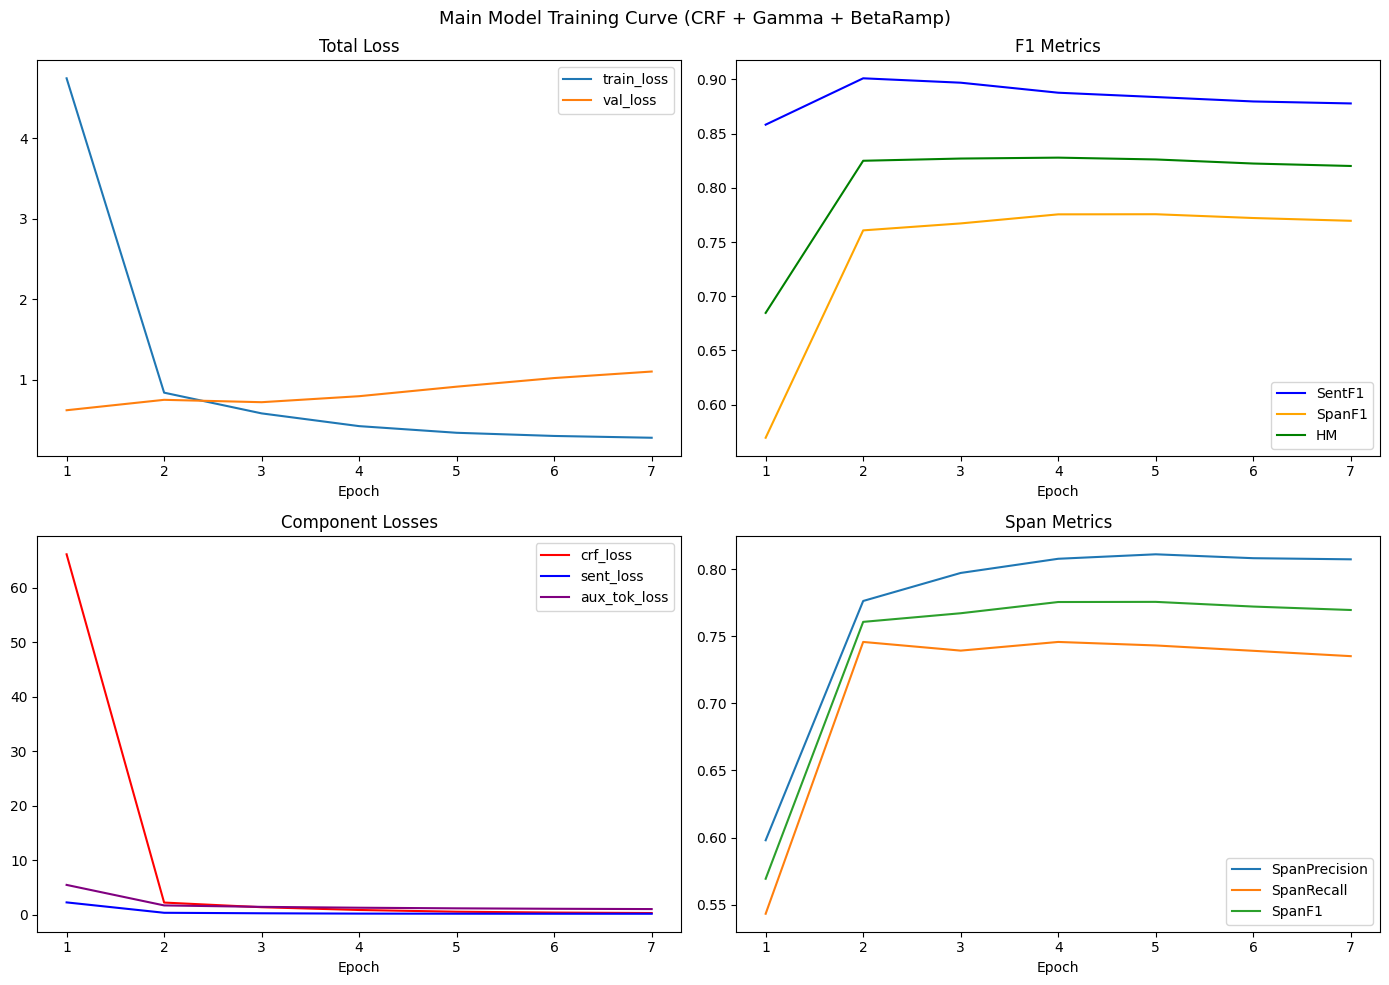

✅ Training curve saved → /content/drive/MyDrive/Colab Datasets/Checkpoints v2/main_bloom_mtl_v2/training_curve_main.png


In [ ]:
if "history_main" in globals() and history_main:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Main Model Training Curve (CRF + Gamma + BetaRamp)", fontsize=13)

    epochs_list = [h["epoch"] for h in history_main]

    ax = axes[0, 0]
    ax.plot(epochs_list, [h["train_loss"]  for h in history_main], label="train_loss")
    ax.plot(epochs_list, [h["val_loss"]    for h in history_main], label="val_loss")
    ax.set_title("Total Loss"); ax.legend(); ax.set_xlabel("Epoch")

    ax = axes[0, 1]
    ax.plot(epochs_list, [h["val_sent_f1"] for h in history_main], label="SentF1", color="blue")
    ax.plot(epochs_list, [h["val_span_f1"] for h in history_main], label="SpanF1", color="orange")
    ax.plot(epochs_list, [h["val_hm"]      for h in history_main], label="HM",     color="green")
    ax.set_title("F1 Metrics"); ax.legend(); ax.set_xlabel("Epoch")

    ax = axes[1, 0]
    ax.plot(epochs_list, [h["crf_loss"]    for h in history_main], label="crf_loss",     color="red")
    ax.plot(epochs_list, [h["sent_loss"]   for h in history_main], label="sent_loss",    color="blue")
    if any(h["aux_tok_loss"] > 0 for h in history_main):
        ax.plot(epochs_list, [h["aux_tok_loss"] for h in history_main], label="aux_tok_loss", color="purple")
    ax.set_title("Component Losses"); ax.legend(); ax.set_xlabel("Epoch")

    ax = axes[1, 1]
    ax.plot(epochs_list, [h["val_span_p"]  for h in history_main], label="SpanPrecision")
    ax.plot(epochs_list, [h["val_span_r"]  for h in history_main], label="SpanRecall")
    ax.plot(epochs_list, [h["val_span_f1"] for h in history_main], label="SpanF1")
    ax.set_title("Span Metrics"); ax.legend(); ax.set_xlabel("Epoch")

    plt.tight_layout()
    _curve_path = f"{MAIN_CKPT_DIR}/training_curve_main.png"
    plt.savefig(_curve_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Training curve saved → {_curve_path}")
else:
    print("⚠️  history_main belum ada. Jalankan Cell 16 terlebih dahulu.")

## **Final Validation Check (Val Set)**

In [ ]:
if "model_main" not in globals():
    print("⚠️  model_main tidak ada di memory. Jalankan Cell 16 terlebih dahulu.")
else:
    print("\nRunning final validation check on val set...")
    model_main.eval()
    _, _val_loader_check = make_dataloaders(MAIN_PARAMS["batch_size"])
    val_preds_check = collect_predictions(
        {"model": model_main, "sentence_only": False},
        _val_loader_check
    )

    _best_t, _best_f1 = 0.5, 0.0
    for _t in np.arange(0.30, 0.90, 0.01):
        _f1_t = f1_score(
            val_preds_check["sent_labels"],
            (val_preds_check["probs"] >= _t).astype(int),
            average="binary", zero_division=0
        )
        if _f1_t > _best_f1:
            _best_f1, _best_t = _f1_t, float(_t)

    _best_preds = (val_preds_check["probs"] >= _best_t).astype(int)
    _val_acc   = accuracy_score(val_preds_check["sent_labels"], _best_preds)
    _val_p, _val_r, _, _ = precision_recall_fscore_support(
        val_preds_check["sent_labels"], _best_preds,
        average="binary", zero_division=0
    )
    try:
        _val_auc = roc_auc_score(val_preds_check["sent_labels"], val_preds_check["probs"])
    except Exception:
        _val_auc = 0.0

    _span_f1 = _span_p = _span_r = 0.0
    if val_preds_check["tok_labels"]:
        try:
            _span_f1 = seqeval_f1(val_preds_check["tok_labels"], val_preds_check["tok_preds"], zero_division=0)
            _span_p  = seqeval_precision(val_preds_check["tok_labels"], val_preds_check["tok_preds"], zero_division=0)
            _span_r  = seqeval_recall(val_preds_check["tok_labels"], val_preds_check["tok_preds"], zero_division=0)
        except Exception as e:
            print(f"  seqeval error: {e}")

    _hm = (2 * _best_f1 * _span_f1 / (_best_f1 + _span_f1)
           if (_best_f1 + _span_f1) > 0 else 0.0)

    print("=" * 55)
    print(f"  FINAL VALIDATION — Main Model (Val Set)")
    print("=" * 55)
    print(f"  Threshold      = {_best_t:.2f}")
    print(f"  Accuracy       = {_val_acc:.4f}")
    print(f"  Precision      = {_val_p:.4f}")
    print(f"  Recall         = {_val_r:.4f}")
    print(f"  SentF1         = {_best_f1:.4f}")
    print(f"  AUC-ROC        = {_val_auc:.4f}")
    print(f"  SpanPrecision  = {_span_p:.4f}")
    print(f"  SpanRecall     = {_span_r:.4f}")
    print(f"  SpanF1         = {_span_f1:.4f}")
    print(f"  Harmonic Mean  = {_hm:.4f}  (F1_sent ⊕ SpanF1)")
    print("=" * 55)
    print(f"\n✅ Checkpoint tersimpan di: {MAIN_CKPT_PATH}")
    print(f"   Lanjutkan ke NB05v2 untuk evaluasi test set.")


Running final validation check on val set...


  FINAL VALIDATION — Main Model (Val Set)
  Threshold      = 0.49
  Accuracy       = 0.8948
  Precision      = 0.8786
  Recall         = 0.9163
  SentF1         = 0.8970
  AUC-ROC        = 0.9612
  SpanPrecision  = 0.7972
  SpanRecall     = 0.7393
  SpanF1         = 0.7672
  Harmonic Mean  = 0.8270  (F1_sent ⊕ SpanF1)

✅ Checkpoint tersimpan di: /content/drive/MyDrive/Colab Datasets/Checkpoints v2/main_bloom_mtl_v2/best_model.pt
   Lanjutkan ke NB05v2 untuk evaluasi test set.


In [ ]:
print("=" * 65)
print("Per-Language Threshold Calibration (Post-Training)")
print("=" * 65)

if "model_main" not in globals():
    print("⚠️  model_main tidak ada. Jalankan Cell 16 terlebih dahulu.")
else:
    print("Menggunakan model_main (sudah di-restore ke HM-best epoch).")
    model_main.eval()

    print("Menjalankan inference pada val set untuk kalibrasi threshold...")
    _, _val_calib_loader = make_dataloaders(MAIN_PARAMS["batch_size"])
    val_calib_preds = collect_predictions(
        {"model": model_main, "sentence_only": False},
        _val_calib_loader
    )

    LANG_CODES_CALIB = ["id", "en", "mixed"]
    lang_thresholds  = {}
    lang_calib_rows  = []

    _best_global_t, _best_global_f1 = 0.5, 0.0
    for _t in np.arange(0.30, 0.90, 0.01):
        _f1_t = f1_score(
            val_calib_preds["sent_labels"],
            (val_calib_preds["probs"] >= _t).astype(int),
            average="binary", zero_division=0
        )
        if _f1_t > _best_global_f1:
            _best_global_f1, _best_global_t = _f1_t, float(_t)
    lang_thresholds["global"] = _best_global_t

    print(f"\n  Global threshold: {_best_global_t:.4f}  (val F1 = {_best_global_f1:.4f})")
    print(f"\n  Per-language threshold calibration:")
    print(f"  {'Lang':>6}  {'N':>6}  {'Threshold':>10}  {'Val F1':>8}  {'Δ vs Global':>12}")
    print(f"  {'─'*6}  {'─'*6}  {'─'*10}  {'─'*8}  {'─'*12}")

    _langs_arr = np.array(val_calib_preds["languages"])
    _probs_arr = val_calib_preds["probs"]
    _labels_arr = val_calib_preds["sent_labels"]

    for lc in LANG_CODES_CALIB:
        _mask = _langs_arr == lc
        _n    = int(_mask.sum())
        if _n == 0:
            lang_thresholds[lc] = _best_global_t
            print(f"  {lc:>6}  {0:>6}  {'N/A':>10}  → pakai global")
            continue

        _probs_lc  = _probs_arr[_mask]
        _labels_lc = _labels_arr[_mask]

        _unique_labels = np.unique(_labels_lc)
        if len(_unique_labels) < 2:
            lang_thresholds[lc] = _best_global_t
            print(f"  {lc:>6}  {_n:>6}  {'skip':>10}  (only one class in subset)")
            continue

        _best_lc_t, _best_lc_f1 = _best_global_t, 0.0
        for _t in np.arange(0.30, 0.90, 0.01):
            _f1_t = f1_score(
                _labels_lc,
                (_probs_lc >= _t).astype(int),
                average="binary", zero_division=0
            )
            if _f1_t > _best_lc_f1:
                _best_lc_f1, _best_lc_t = _f1_t, float(_t)

        lang_thresholds[lc] = _best_lc_t
        _delta = _best_lc_t - _best_global_t
        print(f"  {lc:>6}  {_n:>6}  {_best_lc_t:>10.4f}  {_best_lc_f1:>8.4f}  {_delta:>+12.4f}")

        lang_calib_rows.append({
            "language"          : lc,
            "n_val"             : _n,
            "threshold_global"  : round(_best_global_t, 4),
            "threshold_per_lang": round(_best_lc_t, 4),
            "val_f1_per_lang"   : round(float(_best_lc_f1), 4),
        })

    _thresh_save = {
        "source"           : "best_model_hm.pt (HM-optimized checkpoint)",
        "val_set"          : f"{BIO_DIR}/val_bio.csv",
        "global_threshold" : round(_best_global_t, 4),
        "global_val_f1"    : round(float(_best_global_f1), 4),
        "per_language"     : {
            lc: round(lang_thresholds[lc], 4)
            for lc in ["global"] + LANG_CODES_CALIB
        },
        "calibration_rows" : lang_calib_rows,
        "note"             : (
            "Load JSON ini di NB05 untuk per-language threshold evaluation. "
            "Threshold berasal dari HM-best checkpoint, bukan SentF1-best. "
            "Gunakan per_language dict untuk mapping bahasa ke threshold."
        ),
    }
    _thresh_json_path = f"{RESULT_DIR}/per_lang_thresholds_main_v2.json"
    with open(_thresh_json_path, "w") as _f:
        json.dump(_thresh_save, _f, indent=2)

    print(f"\n  ✅ Per-language thresholds saved → {_thresh_json_path}")
    print(f"     Isi: global={_thresh_save['per_language'].get('global')}, "
          f"id={_thresh_save['per_language'].get('id')}, "
          f"en={_thresh_save['per_language'].get('en')}, "
          f"mixed={_thresh_save['per_language'].get('mixed')}")

    _plang_preds = np.zeros_like(_labels_arr, dtype=int)
    for _lc in LANG_CODES_CALIB:
        _mask = _langs_arr == _lc
        if _mask.any():
            _plang_preds[_mask] = (
                _probs_arr[_mask] >= lang_thresholds[_lc]
            ).astype(int)
    _remaining_mask = ~np.isin(_langs_arr, LANG_CODES_CALIB)
    if _remaining_mask.any():
        _plang_preds[_remaining_mask] = (
            _probs_arr[_remaining_mask] >= _best_global_t
        ).astype(int)

    _pl_acc = accuracy_score(_labels_arr, _plang_preds)
    _pl_p, _pl_r, _pl_f1, _ = precision_recall_fscore_support(
        _labels_arr, _plang_preds, average="binary", zero_division=0
    )
    _pl_span_f1 = 0.0
    if val_calib_preds["tok_labels"]:
        try:
            _pl_span_f1 = seqeval_f1(
                val_calib_preds["tok_labels"],
                val_calib_preds["tok_preds"], zero_division=0
            )
        except Exception:
            pass
    _pl_hm = (
        2 * _pl_f1 * _pl_span_f1 / (_pl_f1 + _pl_span_f1)
        if (_pl_f1 + _pl_span_f1) > 0 else 0.0
    )

    print(f"\n  EVALUASI VAL SET (per-language threshold):")
    print(f"    Accuracy         = {_pl_acc:.4f}")
    print(f"    Precision        = {_pl_p:.4f}")
    print(f"    Recall           = {_pl_r:.4f}")
    print(f"    Sent F1          = {_pl_f1:.4f}  (vs global: {_best_global_f1:.4f})")
    print(f"    Span F1          = {_pl_span_f1:.4f}")
    print(f"    Harmonic Mean    = {_pl_hm:.4f}")

    print(f"   JSON threshold tersimpan dan siap dipakai NB05.")
    print(f"   Di NB05: load '{_thresh_json_path}' dan gunakan")
    print(f"   LANG_THRESHOLD_V2 = json['per_language'] untuk evaluasi.")

Per-Language Threshold Calibration (Post-Training)
Menggunakan model_main (sudah di-restore ke HM-best epoch).
Menjalankan inference pada val set untuk kalibrasi threshold...



  Global threshold: 0.4900  (val F1 = 0.8970)

  Per-language threshold calibration:
    Lang       N   Threshold    Val F1   Δ vs Global
  ──────  ──────  ──────────  ────────  ────────────
      id    1769      0.4500    0.8576       -0.0400
      en    1800      0.4000    0.8213       -0.0900
   mixed    2431      0.7800    0.9869       +0.2900

  ✅ Per-language thresholds saved → /content/drive/MyDrive/Colab Datasets/Results v2/per_lang_thresholds_main_v2.json
     Isi: global=0.49, id=0.45, en=0.4, mixed=0.78

  EVALUASI VAL SET (per-language threshold):
    Accuracy         = 0.8942
    Precision        = 0.8708
    Recall           = 0.9257
    Sent F1          = 0.8974  (vs global: 0.8970)
    Span F1          = 0.7672
    Harmonic Mean    = 0.8272
   JSON threshold tersimpan dan siap dipakai NB05.
   Di NB05: load '/content/drive/MyDrive/Colab Datasets/Results v2/per_lang_thresholds_main_v2.json' dan gunakan
   LANG_THRESHOLD_V2 = json['per_language'] untuk evaluasi.
